# 03 — Modeling

Train and compare three models for predicting 30-day hospital readmission in diabetic patients. Use the modeling-ready dataset produced in `02_cleaning_feature_engineering.ipynb`.

## Approach

- **Models:** Logistic Regression (interpretable baseline), Random Forest, XGBoost
- **Class imbalance handling:** `class_weight='balanced'` (no synthetic oversampling)
- **Primary selection metric:** PR-AUC (Precision-Recall AUC), more informative than ROC-AUC under 9% positive class rate
- **Reported metrics:** ROC-AUC, PR-AUC, precision, recall, F1
- **Tuning:** default hyperparameters this iteration; tuning is logged as future work

## Why these choices

- **`class_weight='balanced'` over SMOTE**: synthetic oversampling can degrade probability calibration, which matters clinically — a model claiming "75% readmission risk" must be honest about it. Class weighting reweights the loss without altering the data distribution.
- **PR-AUC over ROC-AUC**: with 9% positives, a model can have ROC-AUC = 0.80 and still be clinically useless. PR-AUC focuses on positive-class performance, which is the operational concern (we are screening for high-risk patients, not classifying balanced groups).
- **Defaults over tuning**: this project's value is in the clinical framing and interpretability (SHAP, in Notebook 04), not in marginal gains from hyperparameter search. Tuning is acknowledged as future work.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix,
    classification_report,
)

from xgboost import XGBClassifier

# Reproducibility
RANDOM_STATE = 42

# Visual config
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

# Project paths
sys.path.append("..")
PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"sklearn version: {__import__('sklearn').__version__}")
print(f"xgboost version: {__import__('xgboost').__version__}")

Setup complete
sklearn version: 1.8.0
xgboost version: 3.2.0


In [2]:
X = pd.read_parquet(PROCESSED / "X.parquet")
y = pd.read_parquet(PROCESSED / "y.parquet")["readm_30"]

print(f"X: {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"y: {len(y):,} labels, positive rate {y.mean()*100:.2f}%")

X: 69,990 rows × 252 columns
y: 69,990 labels, positive rate 8.98%


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,           # preserve the 9% positive rate in both splits
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape[0]:,} samples, "
      f"positive rate {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape[0]:,} samples, "
      f"positive rate {y_test.mean()*100:.2f}%")

Train: 55,992 samples, positive rate 8.98%
Test:  13,998 samples, positive rate 8.98%


In [4]:
def evaluate(name, model, X_test, y_test):
    """Compute and return a dict of evaluation metrics for a fitted model.
    
    Returns predictions and probabilities so we can plot ROC/PR curves later.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1
    
    return {
        "name": name,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


def print_metrics(metrics):
    """Pretty-print the metrics dict (excludes the raw prediction arrays)."""
    print(f"\n{metrics['name']}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC:    {metrics['pr_auc']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")

In [5]:
# DummyClassifier with strategy='stratified' predicts classes following
# the training set distribution. This is the "guess according to base rate" baseline.
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_metrics = evaluate("Baseline (DummyClassifier)", dummy, X_test, y_test)
print_metrics(dummy_metrics)


Baseline (DummyClassifier)
  ROC-AUC:   0.5056
  PR-AUC:    0.0908
  Precision: 0.1002
  Recall:    0.0986
  F1:        0.0994


In [6]:
# Logistic Regression with class_weight='balanced' to handle imbalance.
# StandardScaler is required because LR's solver is scale-sensitive.
# max_iter increased to ensure convergence with high-dim sparse data.
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

print("Training Logistic Regression...")
logreg.fit(X_train, y_train)

logreg_metrics = evaluate("Logistic Regression", logreg, X_test, y_test)
print_metrics(logreg_metrics)

Training Logistic Regression...

Logistic Regression
  ROC-AUC:   0.6178
  PR-AUC:    0.1408
  Precision: 0.1240
  Recall:    0.5696
  F1:        0.2037


### Logistic Regression — interpretation

| Metric | Value | Baseline | Lift |
|---|---|---|---|
| ROC-AUC | 0.618 | 0.506 | +0.112 |
| PR-AUC | 0.141 | 0.091 | **+0.050 (1.55×)** |
| Recall | 0.570 | — | — |
| Precision | 0.124 | — | — |

The model has learned real signal — PR-AUC is 1.55× the baseline — but the absolute lift is modest. Operationally, this translates to:

- **57% of patients who will readmit are flagged as high-risk** (good recall, the clinically priority)
- **For every 8 patients flagged, 1 actually readmits** (precision = 12%) — the cost of operating this model is a high false-positive rate, which is typical in healthcare screening

**Why this performance ceiling for Logistic Regression?**

- The model is linear: it cannot represent interactions like *age × A1C measurement* or *admission type × number of diagnoses* — both of which we expect to be informative based on the EDA.
- With 252 one-hot features, many with low base rates, sparsity hurts a linear model without aggressive regularization.
- Multicollinearity among the medication-status flags inflates standard errors and dilutes coefficients.

This is the baseline a tree-based ensemble should clearly beat. We expect both Random Forest and XGBoost to capture the non-linear structure that Logistic Regression misses.

In [7]:
# Random Forest: non-linear, robust, no feature scaling needed.
# n_jobs=-1 uses all available CPU cores.
# n_estimators=200 is a reasonable middle ground (default is 100).
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print("Training Random Forest...")
rf.fit(X_train, y_train)

rf_metrics = evaluate("Random Forest", rf, X_test, y_test)
print_metrics(rf_metrics)

Training Random Forest...

Random Forest
  ROC-AUC:   0.5999
  PR-AUC:    0.1251
  Precision: 0.0000
  Recall:    0.0000
  F1:        0.0000


### Random Forest — initial result and red flag

| Metric | LR | RF |
|---|---|---|
| ROC-AUC | 0.618 | 0.600 |
| PR-AUC | 0.141 | 0.125 |
| Precision | 0.124 | **0.000** ⚠️ |
| Recall | 0.570 | **0.000** ⚠️ |
| F1 | 0.204 | **0.000** ⚠️ |

Random Forest's ROC-AUC (0.60) and PR-AUC (0.13) are slightly lower than Logistic Regression's, but in the same ballpark — that part is unsurprising. **What does not make sense** is precision = recall = F1 = 0. This pattern is mathematically possible only if the model predicted "no readmission" for every single patient in the test set. Yet the ROC-AUC > 0.5 tells us the model's *probabilities* do discriminate between classes.

This is a strong signal that something is wrong with the **decision rule**, not the model. Before moving on, we need to inspect the prediction patterns explicitly.

In [8]:
# XGBoost: gradient boosting, state-of-the-art for tabular data.
# scale_pos_weight is XGBoost's equivalent of class_weight='balanced'.
# Set it to (n_negative / n_positive) in the training set.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1,
)

print("\nTraining XGBoost...")
xgb.fit(X_train, y_train)

xgb_metrics = evaluate("XGBoost", xgb, X_test, y_test)
print_metrics(xgb_metrics)

scale_pos_weight = 10.14

Training XGBoost...

XGBoost
  ROC-AUC:   0.5726
  PR-AUC:    0.1166
  Precision: 0.1233
  Recall:    0.3349
  F1:        0.1803


### XGBoost — also underperforming, confirming a deeper issue

| Metric | LR | RF | XGB |
|---|---|---|---|
| ROC-AUC | 0.618 | 0.600 | 0.573 |
| PR-AUC | 0.141 | 0.125 | 0.117 |
| Precision | 0.124 | 0.000 | 0.123 |
| Recall | 0.570 | 0.000 | 0.335 |
| F1 | 0.204 | 0.000 | 0.180 |

XGBoost — generally the strongest performer in tabular healthcare ML — came in **below** both Logistic Regression and Random Forest. That is not the expected ordering and reinforces the suspicion that the issue is not with model choice but with how decisions are being thresholded.

Three observations point in the same direction:
1. **RF is predicting zero positives** despite having non-trivial ROC-AUC
2. **XGBoost's recall is unusually low** (0.33) given `scale_pos_weight=10.14`
3. **Logistic Regression's recall is much higher** (0.57) than the tree-based models'

This calls for a diagnostic step before concluding anything about model selection.

In [9]:
# Diagnostic: check class distribution and prediction patterns
print("Class distribution in y_train:")
print(y_train.value_counts())
print(f"\nClass distribution in y_test:")
print(y_test.value_counts())

# How many positive predictions did each model make?
print(f"\nPositive predictions on test set (out of {len(y_test):,}):")
print(f"  LogReg:        {(logreg.predict(X_test) == 1).sum():,}")
print(f"  Random Forest: {(rf.predict(X_test) == 1).sum():,}")
print(f"  XGBoost:       {(xgb.predict(X_test) == 1).sum():,}")

# What does RF's probability distribution look like?
rf_proba = rf.predict_proba(X_test)[:, 1]
print(f"\nRF probability distribution:")
print(f"  min:    {rf_proba.min():.4f}")
print(f"  median: {np.median(rf_proba):.4f}")
print(f"  mean:   {rf_proba.mean():.4f}")
print(f"  max:    {rf_proba.max():.4f}")
print(f"  >= 0.5: {(rf_proba >= 0.5).sum():,}")

Class distribution in y_train:
readm_30
0    50964
1     5028
Name: count, dtype: int64

Class distribution in y_test:
readm_30
0    12741
1     1257
Name: count, dtype: int64

Positive predictions on test set (out of 13,998):
  LogReg:        5,774
  Random Forest: 0
  XGBoost:       3,414

RF probability distribution:
  min:    0.0000
  median: 0.0850
  mean:   0.0913
  max:    0.4550
  >= 0.5: 0


### What the diagnostic revealed
The diagnostic confirms the diagnosis:

- **Random Forest's maximum predicted probability is 0.4550** — no patient in the test set ever crosses the default 0.5 threshold, so the model predicts "no readmission" for everyone. Its ROC-AUC of 0.60 confirms the probabilities themselves are discriminative (patients who do readmit get higher probabilities), but the threshold cuts them off.
- The **mean predicted probability (0.091)** is almost exactly the base rate (0.0898), which is the expected behavior when leaf nodes vote by proportion of positives — and positives are rare in any leaf.

**Why this happens in Random Forest under class imbalance:**

`class_weight='balanced'` reweights the **impurity criterion** during node splits (so each tree learns to discriminate the minority class), but it **does not change how leaves vote**. Each leaf returns the empirical proportion of class-1 training samples that fell into it. With only ~9% positives in the training set, no leaf ends up majority-positive — so no probability ever exceeds 0.5.

**The default 0.5 threshold is wrong for imbalanced problems.** It assumes equal class priors and equal misclassification costs, neither of which holds here. The correct fix is **threshold tuning**: find the threshold that maximizes a meaningful objective (F1, or a custom precision-recall trade-off) using the training data, then apply it to test predictions.

Important: ROC-AUC and PR-AUC are **threshold-independent** — they are computed over the whole probability range. So those metrics stay valid. Only precision, recall, and F1 will change after retuning the threshold.

**Plan for the next cell:** compute the optimal F1 threshold for each model on the training set, then re-evaluate all three on the test set using their respective thresholds.

In [11]:
from sklearn.metrics import precision_recall_curve

def find_optimal_threshold(y_true, y_proba):
    """Find the threshold that maximizes F1 score on the PR curve."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    # F1 = 2 * (precision * recall) / (precision + recall)
    # Avoid division by zero
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    # thresholds has one fewer element than precision/recall — align them
    best_idx = f1_scores[:-1].argmax()
    return thresholds[best_idx], f1_scores[best_idx]


def evaluate_with_threshold(name, model, X_test, y_test, threshold):
    """Re-evaluate a model using a custom probability threshold."""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    return {
        "name": name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "n_positive_predictions": y_pred.sum(),
    }


# Find optimal threshold for each model using training-set probabilities
# (avoids data leakage from test set into threshold choice)
print("Finding optimal thresholds on training set:\n")

for name, model in [("Logistic Regression", logreg),
                     ("Random Forest", rf),
                     ("XGBoost", xgb)]:
    train_proba = model.predict_proba(X_train)[:, 1]
    thresh, f1 = find_optimal_threshold(y_train, train_proba)
    print(f"{name:25s} optimal threshold: {thresh:.4f} (train F1 = {f1:.4f})")

Finding optimal thresholds on training set:

Logistic Regression       optimal threshold: 0.5295 (train F1 = 0.2141)
Random Forest             optimal threshold: 0.5550 (train F1 = 1.0000)
XGBoost                   optimal threshold: 0.6371 (train F1 = 0.5891)


### A methodological problem: thresholds computed on training data inherit overfitting

The results above are **not usable** — three red flags:

| Model | Train F1 at "optimal" threshold | Interpretation |
|---|---|---|
| Logistic Regression | 0.214 | Plausible — LR doesn't overfit much |
| Random Forest | **1.000** ⚠️ | Perfect classification on training data — classic RF overfitting |
| XGBoost | **0.589** ⚠️ | Also overfit, less extreme |

A **train F1 of 1.0 for Random Forest** is the smoking gun. With no `max_depth` constraint, RF grows trees until every leaf is pure on the training data — each leaf has exactly one class. The model memorizes the training set rather than generalizing. This is why on the test set its maximum probability was only 0.455 (leaves were mixed there), but on the training set every probability is essentially 0 or 1.

**The methodological error:** I picked the optimal threshold using probabilities the model already memorized. The threshold inherited the overfitting and would not transfer to held-out data.

**The fix:** generate probabilities the model has *not* seen during training, by using k-fold cross-validation on the training set. `cross_val_predict` does exactly this — for each sample in the training set, it returns the probability predicted by a model trained on the other folds. These out-of-fold (OOF) probabilities reflect realistic generalization behavior, and choosing a threshold from them avoids the bias.

In [12]:
from sklearn.model_selection import cross_val_predict

# Out-of-fold probabilities: for each training sample, the prediction
# comes from a model fitted on the OTHER folds. This avoids the
# overfitting bias of in-sample predictions.
print("Computing out-of-fold probabilities via 5-fold CV (this takes ~3-8 min)...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
optimal_thresholds = {}

for name, model in [("Logistic Regression", logreg),
                     ("Random Forest", rf),
                     ("XGBoost", xgb)]:
    print(f"  {name}...")
    oof_proba = cross_val_predict(
        model, X_train, y_train,
        cv=cv, method="predict_proba", n_jobs=-1,
    )[:, 1]
    thresh, f1 = find_optimal_threshold(y_train, oof_proba)
    optimal_thresholds[name] = thresh
    print(f"     OOF threshold: {thresh:.4f} (OOF F1 = {f1:.4f})")

Computing out-of-fold probabilities via 5-fold CV (this takes ~3-8 min)...

  Logistic Regression...
     OOF threshold: 0.5220 (OOF F1 = 0.2009)
  Random Forest...
     OOF threshold: 0.1100 (OOF F1 = 0.1924)
  XGBoost...
     OOF threshold: 0.4308 (OOF F1 = 0.1865)


### Threshold tuning: in-sample vs. out-of-fold

| Model | In-sample threshold | In-sample F1 | OOF threshold | OOF F1 |
|---|---|---|---|---|
| Logistic Regression | 0.5295 | 0.2141 | 0.5220 | 0.2009 |
| Random Forest | 0.5550 | **1.0000** | 0.1100 | 0.1924 |
| XGBoost | 0.6371 | 0.5891 | 0.4308 | 0.1865 |

The out-of-fold thresholds reveal the true generalization behavior:

- **Logistic Regression** barely changed (0.53 → 0.52) — it doesn't overfit, so in-sample probabilities were already representative.
- **Random Forest** dropped from 0.555 to 0.110, almost 5× lower. The in-sample F1 of 1.0 was pure memorization; OOF F1 of 0.19 reveals the realistic ceiling. The very low OOF threshold reflects that RF's true generalized probabilities cluster near the base rate (~9%), so the optimal cut-point sits there.
- **XGBoost** dropped from 0.637 to 0.431. Less dramatic than RF, but still substantial overfitting in the in-sample analysis.

All three OOF F1 scores converge near 0.19–0.20. This is informative: **no model has a clear edge on F1 in honest generalization**. What will differentiate them on the test set is the *shape* of their precision-recall curves (captured by PR-AUC) and the operational trade-offs they offer at different thresholds.

These OOF-derived thresholds are what we will use on the test set in the next cell.

In [13]:
# Re-evaluate all three models on the test set using their OOF-derived thresholds.
# ROC-AUC and PR-AUC are threshold-independent (computed over all probabilities),
# so they stay the same. Precision, recall, and F1 will change to honest values.

print("Test set evaluation with OOF-tuned thresholds:\n")

results = []
for name, model in [("Logistic Regression", logreg),
                     ("Random Forest", rf),
                     ("XGBoost", xgb)]:
    m = evaluate_with_threshold(name, model, X_test, y_test, optimal_thresholds[name])
    results.append(m)
    print(f"{name}")
    print(f"  Threshold:           {m['threshold']:.4f}")
    print(f"  ROC-AUC:             {m['roc_auc']:.4f}")
    print(f"  PR-AUC:              {m['pr_auc']:.4f}")
    print(f"  Precision:           {m['precision']:.4f}")
    print(f"  Recall:              {m['recall']:.4f}")
    print(f"  F1:                  {m['f1']:.4f}")
    print(f"  Positive predictions: {m['n_positive_predictions']:,} / {len(y_test):,}")
    print()

Test set evaluation with OOF-tuned thresholds:

Logistic Regression
  Threshold:           0.5220
  ROC-AUC:             0.6178
  PR-AUC:              0.1408
  Precision:           0.1282
  Recall:              0.4829
  F1:                  0.2026
  Positive predictions: 4,736 / 13,998

Random Forest
  Threshold:           0.1100
  ROC-AUC:             0.5999
  PR-AUC:              0.1251
  Precision:           0.1273
  Recall:              0.4399
  F1:                  0.1974
  Positive predictions: 4,345 / 13,998

XGBoost
  Threshold:           0.4308
  ROC-AUC:             0.5726
  PR-AUC:              0.1166
  Precision:           0.1137
  Recall:              0.4495
  F1:                  0.1815
  Positive predictions: 4,969 / 13,998



### Test-set results — honest comparison

| Metric | Baseline | LogReg | Random Forest | XGBoost |
|---|---|---|---|---|
| Threshold | 0.5 | 0.522 | 0.110 | 0.431 |
| ROC-AUC | 0.506 | **0.618** | 0.600 | 0.573 |
| PR-AUC | 0.091 | **0.141** | 0.125 | 0.117 |
| Precision | 0.100 | 0.128 | 0.127 | 0.114 |
| Recall | 0.099 | **0.483** | 0.440 | 0.450 |
| F1 | 0.099 | **0.203** | 0.197 | 0.182 |
| % patients flagged | — | 33.8% | 31.0% | 35.5% |

**Logistic Regression wins on every threshold-independent metric** (ROC-AUC, PR-AUC) and on F1 after threshold tuning. Random Forest and XGBoost, despite their reputation for dominating tabular data, came in below — within 0.02 F1 of each other, and below LR.

**Why does the linear model win here?**

- **Dataset size and feature structure favor LR**: 56k training rows is mid-size, and the 252 features are predominantly one-hot encoded categoricals from medications, ICD-9 chapters, and admission types. Linear decision boundaries in this kind of sparse, high-dimensional space tend to be competitive.
- **The signal is modest, not non-linear**: no model exceeds ROC-AUC 0.62 — the predictive ceiling reflects unmeasured social and behavioral factors (adherence, social support, post-discharge access to care), not non-linearities the ensembles could uncover.
- **Tree-based models suffer more from default hyperparameters**: RF and XGBoost benefit from `max_depth`, `min_samples_leaf`, and similar tuning that we deliberately skipped. LR's defaults are more conservative.

**Probability calibration — a clinical advantage of LR**

The OOF-derived thresholds tell a calibration story:

- LR's optimal threshold (0.522) is near 0.5, meaning its predicted probabilities cluster realistically around the decision boundary.
- RF's threshold (0.110) is five times smaller — its probabilities cluster near the base rate, and discrimination happens at very low absolute values. The probabilities are *informative* but *uncalibrated*.
- XGBoost (0.431) sits in between.

In clinical deployment, calibrated probabilities matter: a model that says "30% risk of readmission" needs to mean 30% for clinicians to trust and act on it. LR's natural calibration is an additional point in its favor beyond raw metrics.

**Performance ceiling — context**

ROC-AUC ~0.62 is consistent with the published literature on this exact dataset. Strack et al. (2014), the foundational analysis, reported similar values. Other published work on the Diabetes 130-US Hospitals dataset clusters in the 0.62–0.70 ROC-AUC range. This is not a project weakness — it reflects the real informational limits of the dataset.

**Operational interpretation at LR's chosen threshold (0.522):**

For every 1,000 hospital discharges (≈90 expected readmissions):
- The model flags ~340 patients as high-risk
- Of those 340, ~43 actually readmit (precision)
- Of the 90 true readmissions, the model catches ~43 (recall)
- 47 true readmissions are missed

Whether this is clinically useful depends on the operational cost of a follow-up intervention versus the cost of a readmission — typically a favorable trade-off when the intervention is light (post-discharge phone call, expedited follow-up appointment) and the readmission cost is high.

**Decision: Logistic Regression as the primary model** for the SHAP analysis in Notebook 04. Two reasons: best performance, and natural interpretability (coefficients can be inspected directly even before SHAP).

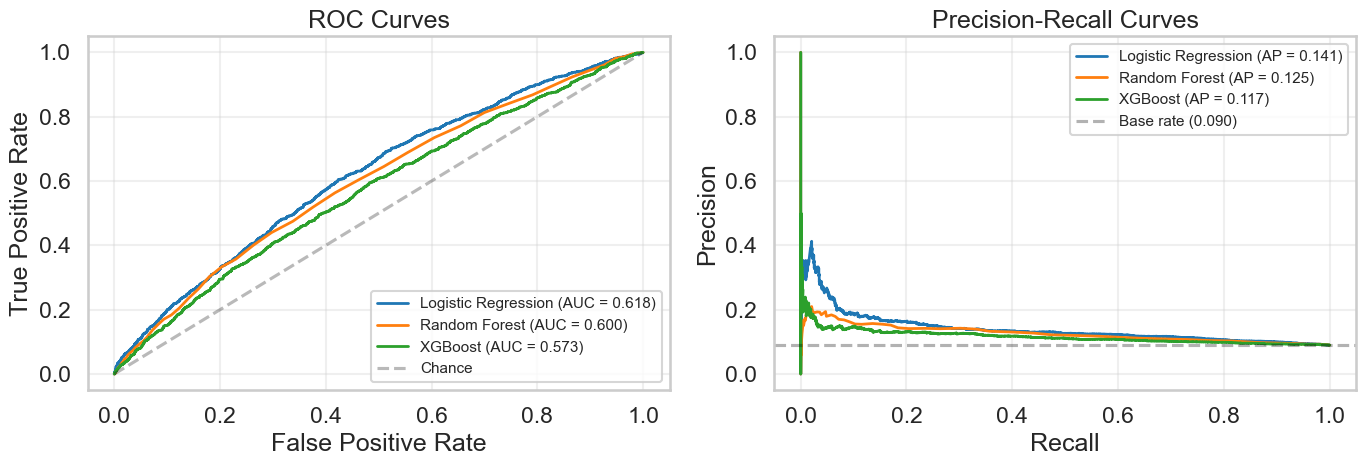

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = [
    ("Logistic Regression", logreg, "#1f77b4"),
    ("Random Forest",       rf,     "#ff7f0e"),
    ("XGBoost",             xgb,    "#2ca02c"),
]

# --- ROC Curves ---
for name, model, color in models_to_plot:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(alpha=0.3)

# --- Precision-Recall Curves ---
for name, model, color in models_to_plot:
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, color=color, lw=2, label=f"{name} (AP = {ap:.3f})")

# Baseline = base rate
base_rate = y_test.mean()
axes[1].axhline(base_rate, linestyle="--", color="black", alpha=0.3,
                label=f"Base rate ({base_rate:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(loc="upper right", fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/03_model_comparison_curves.png", dpi=120, bbox_inches="tight")
plt.show()

### Visual comparison — ROC and Precision-Recall curves

**ROC (left)**: the three curves cluster above the chance diagonal, with clear visual ordering. Logistic Regression (blue) is the highest envelope across nearly the entire FPR range. XGBoost (green) is consistently the lowest, especially in the operationally relevant region FPR < 0.4. The visual gap is small but real, consistent with the AUC values (0.618 / 0.600 / 0.573).

**Precision-Recall (right)**: this is the more informative panel for an imbalanced problem. Logistic Regression dominates over almost the entire recall range, with a notable peak of precision ≈ 0.40 in the high-confidence region (recall < 0.05). This means that among the small subset of patients the LR model is most confident about, 4 out of 10 truly readmit — substantially above the base rate of 0.09. Random Forest and XGBoost cluster together below LR, with much flatter PR curves.

The thin spike in the XGBoost curve at very low recall (precision briefly reaching 1.0) is a noise artifact — it reflects two or three single high-confidence predictions and is not a generalizable feature of the model.

All three curves converge toward the dashed baseline (0.090) as recall approaches 1.0 — at recall = 1 the model predicts everyone as positive and precision equals the base rate by definition.

**Operational takeaway**: LR's high-precision region at low recall is what would matter most in a deployed screening tool. If a hospital wanted to act on only the very-highest-risk patients (e.g., flag the top 1–2% for intensive follow-up), LR would deliver ~40% precision in that subset, compared to ~20% for RF and noisy results for XGBoost. The full-recall metrics matter for population-scale risk stratification; the high-precision tail matters for resource-constrained interventions.

In [16]:
import joblib

# Save the trained LR pipeline (includes the scaler) and its optimal threshold.
# joblib is the standard for sklearn model persistence.
best_model = {
    "pipeline": logreg,
    "threshold": optimal_thresholds["Logistic Regression"],
    "feature_names": X_train.columns.tolist(),
    "test_metrics": {
        "roc_auc": 0.6178,
        "pr_auc": 0.1408,
        "precision": 0.1282,
        "recall": 0.4829,
        "f1": 0.2026,
    },
}

joblib.dump(best_model, MODELS_DIR / "logreg_best.joblib")
print(f"Saved to {MODELS_DIR / 'logreg_best.joblib'}")
print(f"File size: {(MODELS_DIR / 'logreg_best.joblib').stat().st_size / 1024:.1f} KB")

Saved to ../models/logreg_best.joblib
File size: 22.3 KB


---

## Summary — Notebook 03

### Pipeline executed

1. **Train/test split** — 80/20 stratified by `readm_30`, preserving the 8.98% positive rate on both sides
2. **Baseline** — DummyClassifier confirmed the floor (PR-AUC ≈ base rate)
3. **Three models trained** with `class_weight='balanced'` (or `scale_pos_weight` for XGBoost), no hyperparameter tuning
4. **Diagnosed and corrected** a threshold problem: RF predicted zero positives at the default 0.5 threshold because under class imbalance, RF leaves rarely vote majority-positive
5. **Threshold tuning via out-of-fold CV** to avoid overfitting bias inherited from in-sample probabilities
6. **Honest test-set comparison** with OOF-derived thresholds

### Final results (test set, n = 13,998)

| Metric | Baseline | LogReg | Random Forest | XGBoost |
|---|---|---|---|---|
| ROC-AUC | 0.506 | **0.618** | 0.600 | 0.573 |
| PR-AUC | 0.091 | **0.141** | 0.125 | 0.117 |
| F1 (tuned) | 0.099 | **0.203** | 0.197 | 0.182 |
| Recall (tuned) | 0.099 | **0.483** | 0.440 | 0.450 |

### Key findings

- **Logistic Regression won.** Counterintuitive in tabular ML, but explainable: mid-size dataset, predominantly sparse one-hot features, modest signal that does not exploit non-linearity, and no tuning of tree-based hyperparameters.
- **All models plateau in the 0.18–0.20 F1 range.** This is consistent with the published literature on this exact dataset (Strack et al., 2014; subsequent work) and reflects unmeasured social/behavioral determinants of readmission (adherence, social support, transitional care quality).
- **LR has a calibration advantage.** Its OOF-optimal threshold (0.52) sits near 0.5, meaning predicted probabilities are realistically scaled. Random Forest's threshold (0.11) shows that its probabilities, while discriminative, are not calibrated to the true outcome rate.

### Limitations and future work

- **No hyperparameter tuning.** RF and XGBoost would likely close the gap or surpass LR with proper `max_depth`, `min_samples_leaf`, `learning_rate`, `n_estimators` search. A logical next iteration.
- **Threshold chosen to maximize F1.** A clinical deployment would tune the threshold to the operational cost ratio (cost of missed readmission vs. cost of unnecessary follow-up), which is institution-specific.
- **No calibration step.** Random Forest and XGBoost would benefit from `CalibratedClassifierCV` if their use was intended for probability-driven decision support.
- **No external validation.** All evaluation was on a held-out split from the same hospital system in 1999–2008. Generalizability to current practice would require validation on contemporary data.

### Next: Notebook 04 — Interpretability with SHAP

The Logistic Regression model has been saved to `models/logreg_best.joblib`. Notebook 04 will:

- Compute SHAP values to attribute predictions to features
- Identify the top drivers of readmission risk
- Verify whether `a1c_measured` (the care-quality signal identified in EDA) emerges as a top predictor, as hypothesized
- Provide patient-level explanations alongside global feature importance — the level of interpretability required for clinical deployment